In [1]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, LearningCurveDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


data = pd.read_csv("../data_&_analysis/reduced.csv")

data = data[data['text'].notna()]
data = data[data['label'].notna()]

In [2]:
# grouping into labels

mapped_dict = {
    "romance": 0,
    
    "fantasy": 1,
    
    "horror": 2,
    "thriller": 2,
    "crime": 2,
    
    "science": 3,
    "psychology": 3,
    "history": 3,
    "travel": 3,
    "sports": 3
}
class_number = 4


data['label'] = data['label'].map(mapped_dict)


In [3]:
# splitting

X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])

print("Size of training set: ", len(X_train))
print("Size of test set: ", len(X_test))

print("Training set classes distribution: ")
statistics = Y_train.value_counts()
print(statistics)

print("Test set classes distribution:")
statistics = Y_test.value_counts()
print(statistics)



parameters = {
    "n_neighbors": [i for i in range(1,200,5)],
    "metric": ['euclidean'],
    "weights": ['uniform', 'distance']
}



Size of training set:  18380
Size of test set:  4595
Training set classes distribution: 
label
0    5971
1    5663
3    4060
2    2686
Name: count, dtype: int64
Test set classes distribution:
label
0    1492
1    1416
3    1015
2     672
Name: count, dtype: int64


In [4]:
# hyperparameter tuning for KNN with Tfidf Vectorization

tfidf_vectorizer = TfidfVectorizer()

X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], train_size=0.2, stratify=data['label'])
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)
knn_model = KNeighborsClassifier()

grid_search = GridSearchCV(
    knn_model, parameters, cv = 5, scoring="accuracy", n_jobs=1
)

grid_search.fit(X_train, Y_train)

print(f"Best score: {grid_search.best_score_:.4f}")
print(f"Best parameters:\n  {grid_search.best_params_}")

best_params = grid_search.best_params_


# Accuracy on test set for best parameters

knn_model = KNeighborsClassifier(n_neighbors=best_params["n_neighbors"], metric=best_params["metric"], weights=best_params["weights"])
knn_model.fit(X_train, Y_train)

Y_pred = knn_model.predict(X_test)
print("Test set results:")
print(metrics.classification_report(Y_test, Y_pred))


Best score: 0.6884
Best parameters:
  {'metric': 'euclidean', 'n_neighbors': 36, 'weights': 'distance'}
Test set results:
              precision    recall  f1-score   support

           0       0.63      0.90      0.74      5970
           1       0.74      0.72      0.73      5663
           2       0.84      0.27      0.41      2687
           3       0.74      0.64      0.69      4060

    accuracy                           0.69     18380
   macro avg       0.74      0.63      0.64     18380
weighted avg       0.72      0.69      0.68     18380



In [5]:
# hyperparameter tuning for KNN with Tfidf Vectorization

tfidf_vectorizer = TfidfVectorizer(max_features = 500)

X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], train_size=0.2, stratify=data['label'])
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)
knn_model = KNeighborsClassifier()



grid_search = GridSearchCV(
    knn_model, parameters, cv = 5, scoring="accuracy", n_jobs=1
)

grid_search.fit(X_train, Y_train)

print(f"Best score: {grid_search.best_score_:.4f}")
print(f"Best parameters:\n  {grid_search.best_params_}")

best_params = grid_search.best_params_


# Accuracy on test set for best parameters

knn_model = KNeighborsClassifier(n_neighbors=best_params["n_neighbors"], metric=best_params["metric"], weights=best_params["weights"])
knn_model.fit(X_train, Y_train)

Y_pred = knn_model.predict(X_test)
print("Test set results:")
print(metrics.classification_report(Y_test, Y_pred))

Best score: 0.6516
Best parameters:
  {'metric': 'euclidean', 'n_neighbors': 191, 'weights': 'uniform'}
Test set results:
              precision    recall  f1-score   support

           0       0.56      0.93      0.70      5970
           1       0.72      0.63      0.67      5663
           2       0.81      0.26      0.40      2687
           3       0.76      0.49      0.60      4060

    accuracy                           0.64     18380
   macro avg       0.71      0.58      0.59     18380
weighted avg       0.69      0.64      0.62     18380



In [6]:
# hyperparameter tuning for KNN with Tfidf Vectorization

tfidf_vectorizer = TfidfVectorizer(max_features = 50)

X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], train_size=0.2, stratify=data['label'])
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)
knn_model = KNeighborsClassifier()

grid_search = GridSearchCV(
    knn_model, parameters, cv = 5, scoring="accuracy", n_jobs=1
)

grid_search.fit(X_train, Y_train)

print(f"Best score: {grid_search.best_score_:.4f}")
print(f"Best parameters:\n  {grid_search.best_params_}")

best_params = grid_search.best_params_


# Accuracy on test set for best parameters

knn_model = KNeighborsClassifier(n_neighbors=best_params["n_neighbors"], metric=best_params["metric"], weights=best_params["weights"])
knn_model.fit(X_train, Y_train)

Y_pred = knn_model.predict(X_test)
print("Test set results:")
print(metrics.classification_report(Y_test, Y_pred))

Best score: 0.5484
Best parameters:
  {'metric': 'euclidean', 'n_neighbors': 71, 'weights': 'distance'}
Test set results:
              precision    recall  f1-score   support

           0       0.56      0.75      0.64      5970
           1       0.49      0.57      0.53      5663
           2       0.55      0.20      0.30      2687
           3       0.56      0.40      0.46      4060

    accuracy                           0.54     18380
   macro avg       0.54      0.48      0.48     18380
weighted avg       0.54      0.54      0.52     18380



In [7]:
# hyperparameter tuning for KNN with Tfidf Vectorization

tfidf_vectorizer = TfidfVectorizer(max_features=1000)

X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], train_size=0.2, stratify=data['label'])
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)
knn_model = KNeighborsClassifier()

grid_search = GridSearchCV(
    knn_model, parameters, cv = 5, scoring="accuracy", n_jobs=1
)

grid_search.fit(X_train, Y_train)

print(f"Best score: {grid_search.best_score_:.4f}")
print(f"Best parameters:\n  {grid_search.best_params_}")

best_params = grid_search.best_params_


# Accuracy on test set for best parameters

knn_model = KNeighborsClassifier(n_neighbors=best_params["n_neighbors"], metric=best_params["metric"], weights=best_params["weights"])
knn_model.fit(X_train, Y_train)

Y_pred = knn_model.predict(X_test)
print("Test set results:")
print(metrics.classification_report(Y_test, Y_pred))

Best score: 0.6892
Best parameters:
  {'metric': 'euclidean', 'n_neighbors': 66, 'weights': 'distance'}
Test set results:
              precision    recall  f1-score   support

           0       0.69      0.84      0.76      5970
           1       0.62      0.81      0.70      5663
           2       0.86      0.24      0.38      2687
           3       0.75      0.56      0.64      4060

    accuracy                           0.68     18380
   macro avg       0.73      0.61      0.62     18380
weighted avg       0.71      0.68      0.66     18380



In [4]:
def plot_confusion_matrix(Y, Y_pred, title, target_labels):
    matrix = metrics.confusion_matrix(Y, Y_pred, labels=target_labels)
    matrix_df = pd.DataFrame(matrix, columns=np.unique(target_labels), index=np.unique(target_labels))
    f, ax = plt.subplots(figsize=(10,5))
    ax = sns.heatmap(matrix_df, annot=True, fmt="g", cmap = "OrRd")

    ax.set_xlabel("Predicted values")
    ax.set_ylabel("Real values")
    ax.xaxis.set_ticklabels(target_labels)
    ax.yaxis.set_ticklabels(target_labels)
    
    plt.title(title)
    plt.show()

1994
Accuracy:  0.7103373231773668


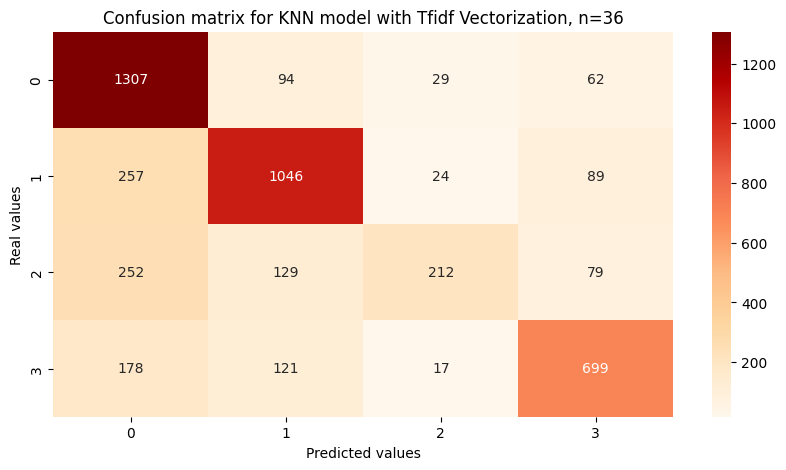

Accuracy:  0.6537540805223069


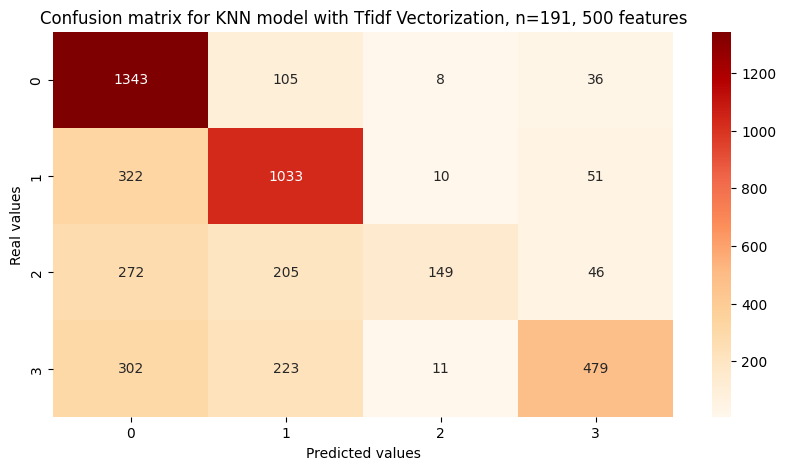

Accuracy:  0.5397170837867247


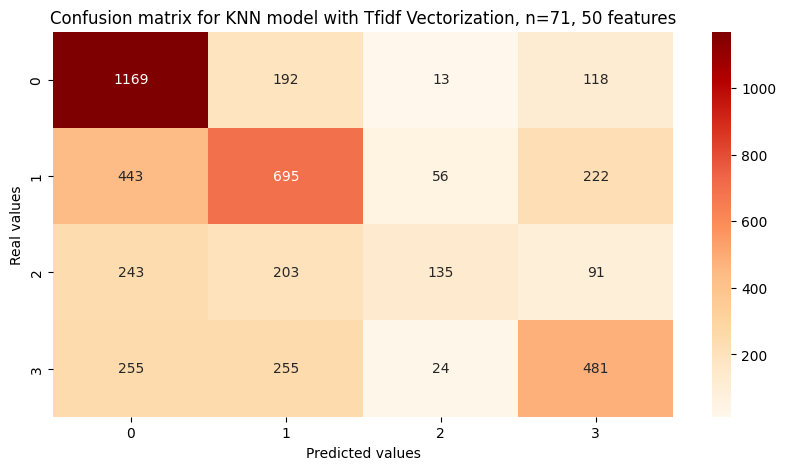

Accuracy:  0.5912948857453754


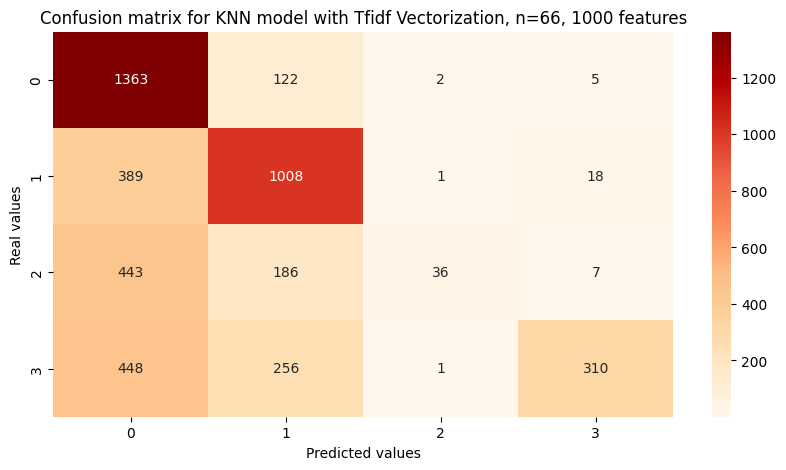

In [6]:
tfidf_vectorizer=TfidfVectorizer()

# 41 neighbor KNN
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="distance", n_neighbors=36)
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print(np.sum(np.where(Y_pred==0,1,0)))
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))
plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Tfidf Vectorization, n=36", [0,1,2,3])


# 116 neighbors KNN
tfidf_vectorizer = TfidfVectorizer(max_features=500)
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="distance", n_neighbors=191)
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))
plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Tfidf Vectorization, n=191, 500 features", [0,1,2,3])



# 31 neighbors KNN
tfidf_vectorizer = TfidfVectorizer(max_features=50)
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="uniform", n_neighbors=71)
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))
plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Tfidf Vectorization, n=71, 50 features", [0,1,2,3])

# 30 neighbors KNN
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])
knn_model = KNeighborsClassifier(metric="euclidean", weights="distance", n_neighbors=66)
X_train = tfidf_vectorizer.fit_transform(X_train)
X_test = tfidf_vectorizer.transform(X_test)
knn_model.fit(X_train, Y_train)
Y_pred = knn_model.predict(X_test)
print("Accuracy: ", metrics.accuracy_score(Y_test, Y_pred))
plot_confusion_matrix(Y_test, Y_pred, "Confusion matrix for KNN model with Tfidf Vectorization, n=66, 1000 features", [0,1,2,3])

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(data['text'], data['label'], test_size=0.2, stratify=data['label'])

count_vectorizer = CountVectorizer()

X_train = count_vectorizer.fit_transform(X_train)
X_test = count_vectorizer.transform(X_test)

knn_model = KNeighborsClassifier()

parameters = {
    "n_neighbors": [i for i in range(1,200,5)],
    "metric": ['euclidean'],
    "weights": ['uniform']
}

grid_search = GridSearchCV(
    knn_model, parameters, cv = 5, scoring="accuracy", n_jobs=1
)

grid_search.fit(X_train, Y_train)

print(f"Best score: {grid_search.best_score_:.4f}")
print(f"Best parameters:\n  {grid_search.best_params_}")


Best score: 0.4212
Best parameters:
  {'metric': 'euclidean', 'n_neighbors': 21, 'weights': 'uniform'}


In [12]:
# Accuracy on test set for best parameters

best_params = grid_search.best_params_
knn_model = KNeighborsClassifier(n_neighbors=best_params["n_neighbors"], metric=best_params["metric"], weights=best_params["weights"])
knn_model.fit(X_train, Y_train)

Y_pred = knn_model.predict(X_test)
print("Test set results:")
print("ACC", knn_model.score(X_test, Y_test))
print(metrics.classification_report(Y_test, Y_pred))

Test set results:
ACC 0.4454842219804135
              precision    recall  f1-score   support

           0       0.40      0.79      0.54      1492
           1       0.52      0.30      0.38      1416
           2       0.81      0.08      0.15       672
           3       0.48      0.38      0.42      1015

    accuracy                           0.45      4595
   macro avg       0.56      0.39      0.37      4595
weighted avg       0.52      0.45      0.41      4595

